In [24]:
# imports
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from pathlib import Path

In [25]:
# identify paths/set constants
train_dir = Path("../data/Training")
test_dir = Path("../data/Testing")

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42
EPOCHS = 10

In [26]:
# load datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print(class_names)


Found 5524 files belonging to 4 classes.
Using 4420 files for training.
Found 5524 files belonging to 4 classes.
Using 1104 files for validation.
Found 554 files belonging to 4 classes.
['glioma', 'meningioma', 'notumor', 'pituitary']


In [27]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [28]:
# build the baseline CNN
    # standard architecture

    # Conv2D learns visual features.
    # MaxPooling2D reduces image size while keeping important information.
    # Dense layers make the final classification.
    # Dropout helps reduce overfitting.
    # softmax outputs probabilities for the 4 classes
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation="softmax")
])

model.summary()

# Detects patterns/features
# Shrinks the image spatially
# Learns higher-level tumor features
# Makes a final 4-class prediction

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# compile
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [30]:
# train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 85s 294ms/step - accuracy: 0.6462 - loss: 0.8530 - val_accuracy: 0.8297 - val_loss: 0.5198
Epoch 2/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 79s 279ms/step - accuracy: 0.8072 - loss: 0.5173 - val_accuracy: 0.8370 - val_loss: 0.3892
Epoch 3/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 71s 251ms/step - accuracy: 0.8475 - loss: 0.3899 - val_accuracy: 0.9040 - val_loss: 0.2610
Epoch 4/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 73s 258ms/step - accuracy: 0.8939 - loss: 0.2868 - val_accuracy: 0.9067 - val_loss: 0.2431
Epoch 5/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 75s 266ms/step - accuracy: 0.9192 - loss: 0.2203 - val_accuracy: 0.9176 - val_loss: 0.1953
Epoch 6/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 83s 294ms/step - accuracy: 0.9265 - loss: 0.1855 - val_accuracy: 0.9321 - val_loss: 0.1739
Epoch 7/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 93s 328ms/step - accuracy: 0.9425 - loss: 0.1513 - val_accuracy: 0.9275 - val_loss: 0.2020
Epoch 8/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 101s 356ms/step - accuracy: 0.9545 - loss: 

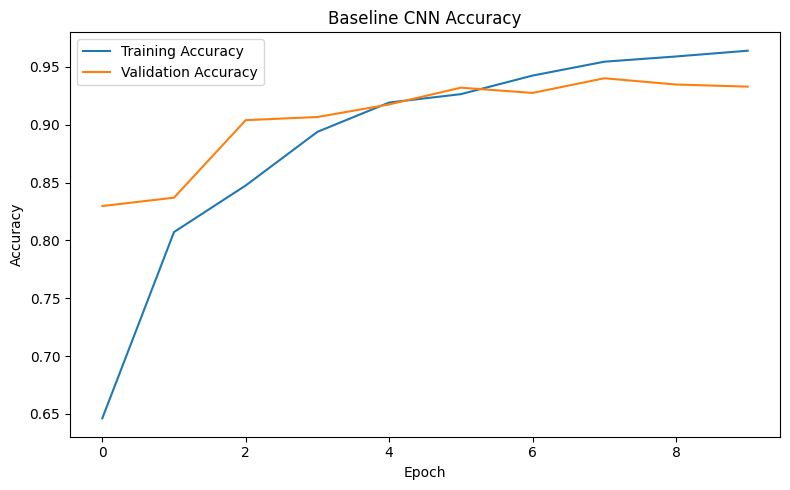

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Baseline CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.savefig("../figures/baseline_cnn_accuracy.png", dpi=300)
plt.show()

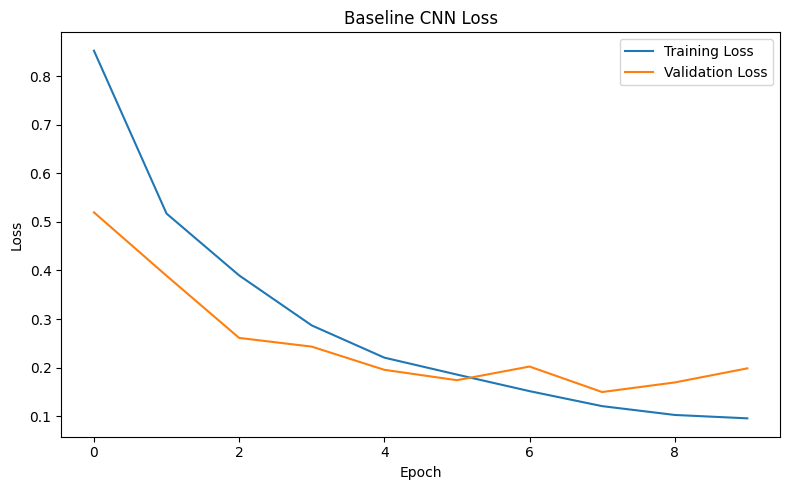

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Baseline CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig("../figures/baseline_cnn_loss.png", dpi=300)
plt.show()

In [33]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - accuracy: 0.9170 - loss: 0.2952
Test Loss: 0.2952039837837219
Test Accuracy: 0.916967511177063


In [34]:
model.save("../models/baseline_cnn.keras")

## Baseline CNN Summary

This notebook trained a simple convolutional neural network from scratch for multiclass brain MRI tumor classification. The baseline model provides a reference point for evaluating whether transfer learning models such as MobileNetV2 and EfficientNetB0 improve classification performance. Training and validation accuracy/loss curves were saved for later comparison in the final report.
